inconsistent documentation for now


the project will be as following <br>
0 opening the dataset <br>
1 DATA CLEANING <br>
1.1 Loading the dataset and importing the libraries<br>
1.2 missing values <br>
1.3 imputation using data from the names (not best practice)<br>
1.4 dropping missing values to avoid imputation involving categorical data<br>
1.5 binary econcoding categorical data<br>
1.6 gini index<br>
1.7 information gain<br>
2 DATA VIZUALIZATION
2.1 <br>

<h4 align = "center">0  Loading the dataset and importing the libraries</h4>


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import category_encoders as ce
from copy import deepcopy
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

file_path = r"D:\ML\videogames_predictions\video games sales.csv" # modify the link with your local install of the csv

df = pd.read_csv(file_path, encoding='ISO-8859-1')

In [2]:
df.head() # gives us a short insight into how the df look visually

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
df.info() # tells us what will need to be encoded
# we will encode strings because ML models need encoded categorical data.

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


<h4 align = "center"> 1.1 Counting missing values and removing the mistake entry</h4>

since the dataset contains 10K+ entries, the first step will be understanding how much of it is actually useable.<br>


In [4]:
print(df.isnull().sum())

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


we will delete the entry that has year set to 2020 because it was a mistake when collecting data, all out data stops at ~2015 besides this one.

In [5]:
df.loc[[df["Year"].idxmax()]] #if you add code below make sure to print this.

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
5957,5959,Imagine: Makeup Artist,DS,2020.0,Simulation,Ubisoft,0.27,0.0,0.0,0.02,0.29


In [6]:
df = df.drop(df["Year"].idxmax())

<h4 align = "center"> 1.2 simple imputation using the names to complete the years </h4>

the code below creates a temporary df that will be used to extract the years from the game names that end with a year assuming the game was published $\pm$ 1 year away from the one in the name<br>
the assumption was made because the games that end with a year are mostly sport games, note that games like the more recent "Cyberpunk 2077" could introduce an outlier into the data, resulting is worse models.

In [7]:
null_rows = df[df.isnull().any(axis=1)]

#slices each name and checks is the last 4 characters are digits
null_rows = null_rows[null_rows['Name'].str[-4:].str.isdigit() == True]

with pd.option_context('display.max_rows', None, 'display.max_columns', None): print(null_rows) #allows you to see the whole df without the annoying .tostring formatting

        Rank                               Name Platform    Year       Genre  \
179      180                    Madden NFL 2004      PS2     NaN      Sports   
377      378                   FIFA Soccer 2004      PS2     NaN      Sports   
470      471         wwe Smackdown vs. Raw 2006      PS2     NaN    Fighting   
1649    1651                NASCAR Thunder 2003      PS2     NaN      Racing   
3501    3503                    Madden NFL 2002       XB     NaN      Sports   
4797    4799                   NFL GameDay 2003      PS2     NaN      Sports   
5162    5164                      NBA Live 2003       XB     NaN      Sports   
5669    5671             All-Star Baseball 2005      PS2     NaN      Sports   
5901    5903                      NBA Live 2003       GC     NaN      Sports   
8929    8931             All-Star Baseball 2005       XB     NaN      Sports   
9517    9519             Farming Simulator 2011       PC  2010.0  Simulation   
12922  12924                Tour de Fran

name_dict will store the games names as keys and the approximated years extracted as values, the dict will be used as a temporary way to store the data before being added to the main dataframe.

In [8]:
name_dict = {
    row: row[-4:]
    for row in null_rows['Name']
    if str(row)[-4:].isdigit() and len(str(row)) >= 4
}
print(name_dict)

{'Madden NFL 2004': '2004', 'FIFA Soccer 2004': '2004', 'wwe Smackdown vs. Raw 2006': '2006', 'NASCAR Thunder 2003': '2003', 'Madden NFL 2002': '2002', 'NFL GameDay 2003': '2003', 'NBA Live 2003': '2003', 'All-Star Baseball 2005': '2005', 'Farming Simulator 2011': '2011', 'Tour de France 2011': '2011', 'Sega Rally 2006': '2006', 'Football Manager 2007': '2007', 'PDC World Championship Darts 2008': '2008', 'Driving Simulator 2011': '2011'}


filling the empty data with approximated release years

In [9]:
df['Year'] = df['Year'].fillna(df['Name'].map(name_dict))
print(df.isnull().sum())
print( f"total number of dirty rows is {df.isnull().any(axis=1).sum()}")

Rank              0
Name              0
Platform          0
Year            256
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64
total number of dirty rows is 293


originally there were 271 missing values for the "Year" column, now there are 256, 15 entries were added but the publisher column stayed the same.

In [10]:
count = df.query("Publisher == 'Unknown'").shape[0]
print(count)

203


<h4 align = "center"> 1.3 Treating the rest of the missing values</h4>

the missing name of publishers will be filled by the imputer later on in the pipeline, for now the Unknown category will be extended and used as a way to store games from publishers with 3 or less games, so that we can train proper models

In [11]:
print((df['Platform'].value_counts() <= 3).sum())
print((df['Publisher'].value_counts() <= 3).sum())

platform_counts = df['Platform'].value_counts()
publisher_counts = df['Publisher'].value_counts()

df['Platform'] = df['Platform'].map(lambda x: 'Other' if (pd.isna(x) or platform_counts[x] <= 3) else x)
df['Publisher'] = df['Publisher'].map(lambda x: 'Unknown' if( pd.isna(x) or publisher_counts[x] <= 3) else x)

#quantities
print((df['Platform'] == "Other").sum())
print((df['Publisher'] == "Unknown").sum())

#reassuring the values got transformed
print((df['Platform'].value_counts() <= 3).sum())
print((df['Publisher'].value_counts() <= 3 ).sum())

4
314
7
749
0
0


comparing the combined small game publishers with a big game publisher we find out that the games are mostly similar

In [12]:
unknown_publisher = np.array([df.loc[df['Publisher'] == 'Unknown', 'Global_Sales']])
std = unknown_publisher.std()
mean = unknown_publisher.mean()
print(std,mean)

activision = np.array([df.loc[df['Publisher'] == 'Activision', 'Global_Sales']])
std = activision.std()
mean = activision.mean()
print(std,mean)

0.37282967394226685 0.18558077436582113
1.6328857474405882 0.7461128205128206


much better situation for the platform but as before, smaller deviation than industry standards

In [13]:
unknown_platform = np.array([df.loc[df['Platform'] == 'Other', 'Global_Sales']])
std = unknown_platform.std()
mean = unknown_platform.mean()
print(std,mean)

PS4 = np.array([df.loc[df['Platform'] == 'PS4', 'Global_Sales']])
std = PS4.std()
mean = PS4.mean()
print(std,mean)

0.040254293724586776 0.04714285714285715
1.6165547849900261 0.8276785714285715


In [14]:
df = df.dropna()

In [15]:
print(df.isnull().sum())

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


<h4 align = "center"> 1.5 transforming Year to int</h4>
this step will ensure year is an integer for easier computation

In [16]:
df["Year"] = pd.to_numeric(df["Year"], downcast='integer')
df_aux = deepcopy(df)  # copy of the df that will be later used in the pipeline
df.info()

<class 'pandas.DataFrame'>
Index: 16341 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16341 non-null  int64  
 1   Name          16341 non-null  str    
 2   Platform      16341 non-null  str    
 3   Year          16341 non-null  int16  
 4   Genre         16341 non-null  str    
 5   Publisher     16341 non-null  str    
 6   NA_Sales      16341 non-null  float64
 7   EU_Sales      16341 non-null  float64
 8   JP_Sales      16341 non-null  float64
 9   Other_Sales   16341 non-null  float64
 10  Global_Sales  16341 non-null  float64
dtypes: float64(5), int16(1), int64(1), str(4)
memory usage: 1.4 MB


<h4 align = "center"> 1.6 categorical data counts</h4>

the next step is to account for the data that is not numerical, since ML models do not do well with categorical data

In [17]:
print(df["Genre"].unique())
print("_"*100)
print(df["Platform"].unique())
print("_"*100)
print(df["Publisher"].unique())


<StringArray>
[      'Sports',     'Platform',       'Racing', 'Role-Playing',
       'Puzzle',         'Misc',      'Shooter',   'Simulation',
       'Action',     'Fighting',    'Adventure',     'Strategy']
Length: 12, dtype: str
____________________________________________________________________________________________________
<StringArray>
[  'Wii',   'NES',    'GB',    'DS',  'X360',   'PS3',   'PS2',  'SNES',
   'GBA',   '3DS',   'PS4',   'N64',    'PS',    'XB',    'PC',  '2600',
   'PSP',  'XOne',    'GC',  'WiiU',   'GEN',    'DC',   'PSV',   'SAT',
   'SCD',    'WS',    'NG', 'Other']
Length: 28, dtype: str
____________________________________________________________________________________________________
<StringArray>
[                   'Nintendo',      'Microsoft Game Studios',
        'Take-Two Interactive', 'Sony Computer Entertainment',
                  'Activision',                     'Ubisoft',
          'Bethesda Softworks',             'Electronic Arts',
       

since there are 31 platforms, 12 Genres and 576 publishers, I am going to use binary encoding<br>
with one hot encoding, the minumum number would be 30+11+575 wich ends up being 616 additional columns, wich is not good.

In [18]:
print(df["Genre"].value_counts())
print(f"there are {len(pd.unique(df['Genre']))} genres")

Genre
Action          3253
Sports          2315
Misc            1710
Role-Playing    1471
Shooter         1282
Adventure       1276
Racing          1229
Platform         876
Simulation       850
Fighting         837
Strategy         671
Puzzle           571
Name: count, dtype: int64
there are 12 genres


In [19]:
print(df["Platform"].value_counts())
print(f"there are {len(pd.unique(df['Platform']))} platforms")

Platform
PS2      2134
DS       2133
PS3      1304
Wii      1290
X360     1237
PSP      1198
PS       1189
PC        943
GBA       811
XB        806
GC        543
3DS       500
PSV       412
PS4       336
N64       316
SNES      239
XOne      213
SAT       173
WiiU      143
2600      116
NES        98
GB         97
DC         52
GEN        27
NG         12
Other       7
SCD         6
WS          6
Name: count, dtype: int64
there are 28 platforms


In [20]:
print(df["Publisher"].value_counts())
print(f"there are {len(pd.unique(df['Publisher']))} publishers")

Publisher
Electronic Arts                 1343
Activision                       966
Namco Bandai Games               928
Ubisoft                          917
Konami Digital Entertainment     823
                                ... 
7G//AMES                           4
System Soft                        4
Slitherine Software                3
Funsta                             3
TopWare Interactive                2
Name: count, Length: 264, dtype: int64
there are 264 publishers


<h1 align = "center">2 DATA VIZUALIZATION </H1>

<h4 align = "center"> 2.1 pie chart of game publishers </h4>

Text(0.5, 1.0, 'pie chart of Publisher')

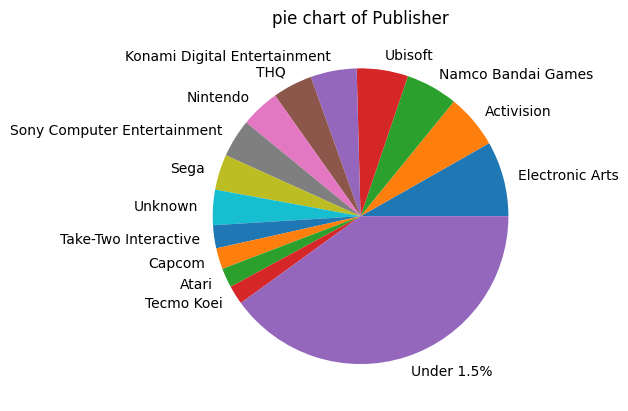

In [21]:
publisher_counts = df['Publisher'].value_counts()
total = publisher_counts.sum()

mask = publisher_counts / total >= 0.015
above = publisher_counts[mask]
below_sum = publisher_counts[~mask].sum()

publisher_counts = pd.concat([above, pd.Series({'Under 1.5%': below_sum})])

ax = publisher_counts.plot.pie(labels=publisher_counts.index)
plt.title("pie chart of Publisher")

<h4 align = "center"> 2.2 pie chart of platforms </h4>

Text(0.5, 1.0, 'pie chart of Platforms')

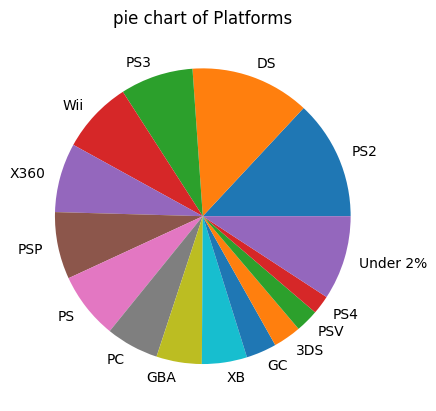

In [22]:
publisher_counts = df['Platform'].value_counts()
total = publisher_counts.sum()

mask = publisher_counts / total >= 0.02
above = publisher_counts[mask]
below_sum = publisher_counts[~mask].sum()

publisher_counts = pd.concat([above, pd.Series({'Under 2%': below_sum})])

ax = publisher_counts.plot.pie(labels=publisher_counts.index)
plt.title("pie chart of Platforms")

<h4 align = "center"> 2.3 pie chart of categories </h4>

Text(0.5, 1.0, 'pie chart of Genres')

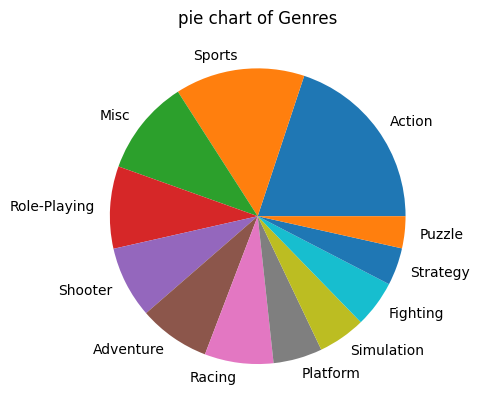

In [23]:
df["Genre"].value_counts().plot.pie()
plt.title("pie chart of Genres")

<h4 align = "center"> 2.4 hist of years</h4>

Text(0.5, 1.0, 'histogram of years')

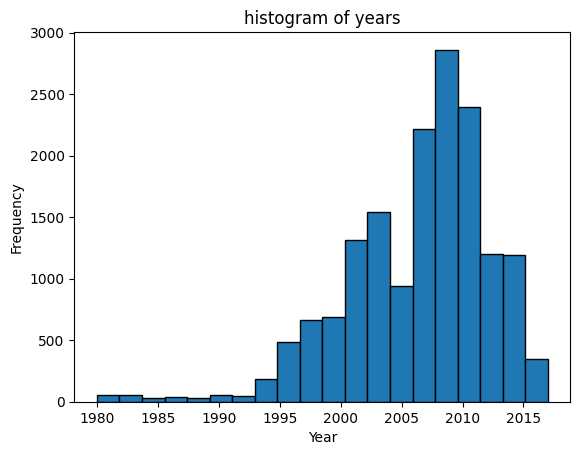

In [24]:
df["Year"].plot.hist(bins = 20,edgecolor="black")
plt.xlabel("Year")
plt.title("histogram of years")

<h4 align = "center"> 2.5 histograms of sales</h4>

all of these are left skewed and will be log scaled for more accurate models.

In [25]:
def histcharge(x, upper_limit = 0.8):
    x.plot.hist(bins=15,edgecolor="black",range=[0,upper_limit])
    arr = np.array(x)
    mean = arr.mean()
    std = arr.std()
    print(mean,std)

0.2656961018297534 0.821896331515716


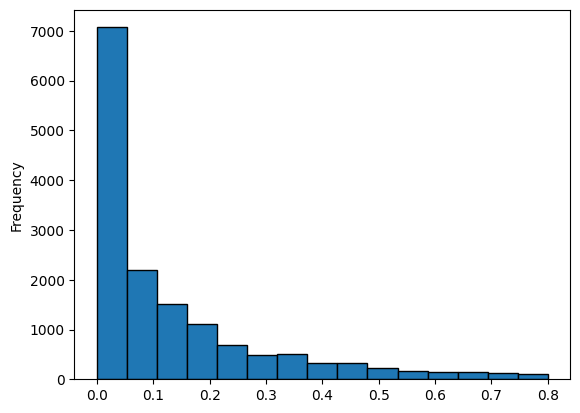

In [26]:
histcharge(df['NA_Sales'])

0.1477082185912735 0.5088862913251831


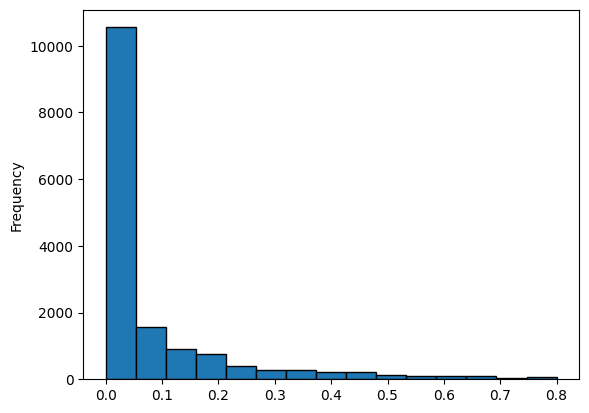

In [27]:
histcharge(df['EU_Sales'])

0.0785992289333578 0.31142139223472803


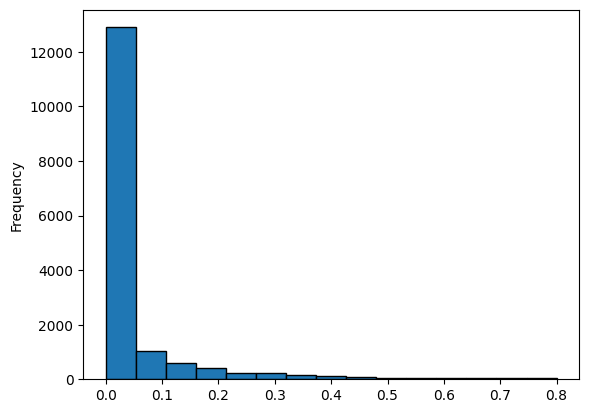

In [28]:
histcharge(df["JP_Sales"])

0.04840217856924301 0.18992862603226204


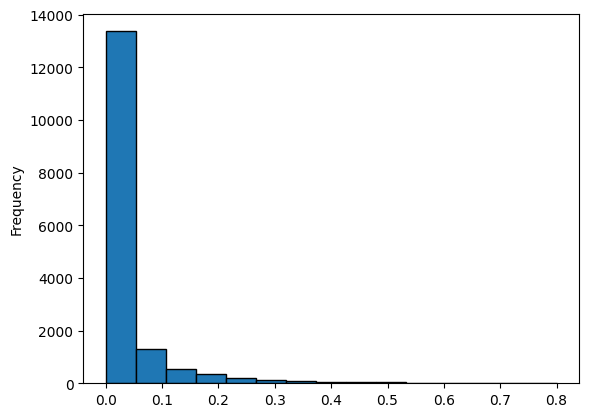

In [29]:
histcharge(df["Other_Sales"])

0.5406804969096138 1.5657708593519484


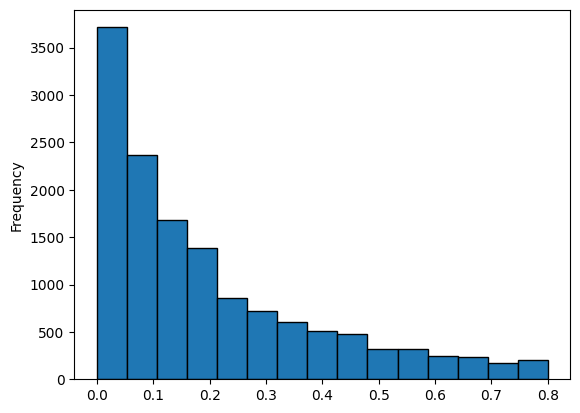

In [30]:
histcharge(df["Global_Sales"])

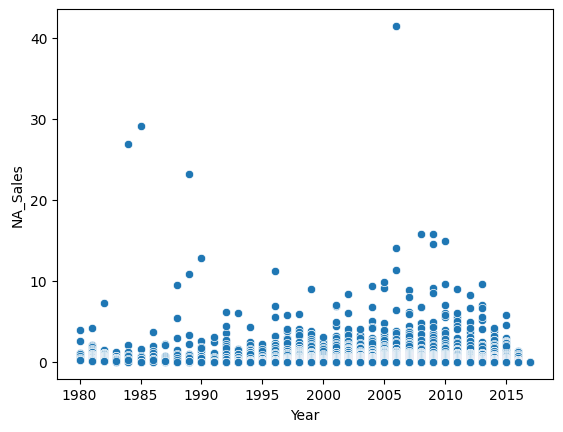

In [31]:
def scatter(sale) : sns.scatterplot(data = df,x = "Year",y=sale)
scatter("NA_Sales")

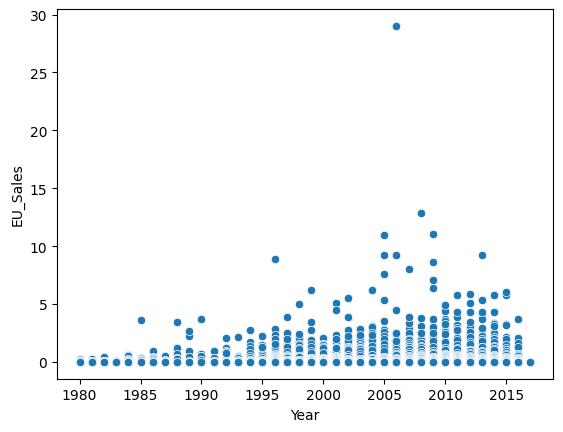

In [32]:
scatter("EU_Sales")

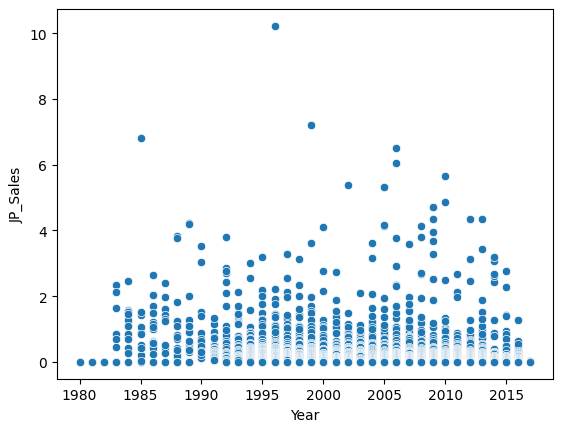

In [33]:
scatter("JP_Sales")

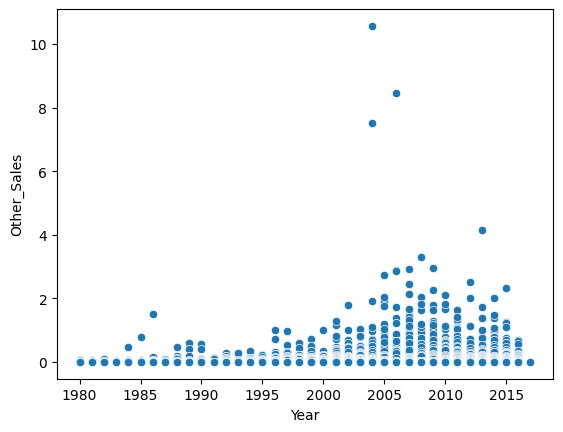

In [34]:
scatter("Other_Sales")

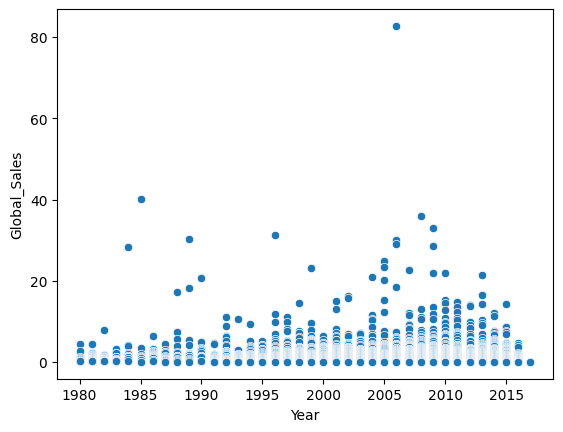

In [35]:
scatter("Global_Sales")

<h4 align = "center"> 1.6 Pearson s correlation </h4>

running a pearson s correlation for numeric data alone is a good way to see if I have any global liniarity,despite having some cases of multicolinearity with values of .9 and up (one even hitting 0.94) caused by the fact that global sales is a sum of the other specific sales. <br>
we can do almost nothing with correlations between various sales
since this is missing all the categorical variables, years do not have a high correlation with any other numerical field, and as stated above we cannot do anything with the corr of different sales we will steer away from any sort of linear model

In [36]:
df.corr(numeric_only=True)

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Rank,1.000000,0.179139,-0.400607,-0.379281,-0.268920,-0.333002,-0.427205
Year,0.179139,1.000000,-0.091522,0.005917,-0.169244,0.040879,-0.074836
NA_Sales,-0.400607,-0.091522,1.000000,0.768139,0.450824,0.634865,0.941167
EU_Sales,-0.379281,0.005917,0.768139,1.000000,0.436056,0.726204,0.902959
JP_Sales,-0.268920,-0.169244,0.450824,0.436056,1.000000,0.290368,0.612428
Other_Sales,-0.333002,0.040879,0.634865,0.726204,0.290368,1.000000,0.748246
Global_Sales,-0.427205,-0.074836,0.941167,0.902959,0.612428,0.748246,1.000000


<h4 align = "center"> 1.8 label encoding </h4><br>
despite the fact that this is not the best and proper way to encode nominal categorical data that, for the sake of a peek at what is and is not relevant it is sufficient.

label encoding for the genie impurity, for information gain, and mutual information

In [37]:
df_analysis = df[['Genre', 'Platform', 'Publisher','Year','Global_Sales']].copy()

for col in ['Genre', 'Platform', 'Publisher']: df_analysis[col] = LabelEncoder().fit_transform(df_analysis[col].astype(str))
df_analysis.head()

,Genre,Platform,Publisher,Year,Global_Sales
0,10,23,162,2006,82.74
1,4,9,162,1985,40.24
2,6,23,162,2008,35.82
3,10,23,162,2009,33.00
4,7,4,162,1996,31.37


<h4 align = "center"> 1.9 information gain </h4>

we will first use information gain in order to know if there is a relationship between eace feauture and the target, it is based on "entropy estimation from k-nearest neighbors distances" (sklearn mutual_info_regression documentation), this will help decide the feautures used in the actual model training and testing

Genre        0.033858
Year         0.051147
Platform     0.086227
Publisher    0.162821
dtype: float64


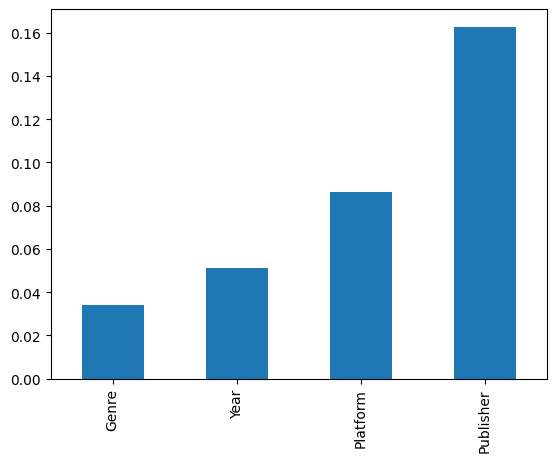

In [38]:
df_analysis = df_analysis.dropna()
y = df_analysis['Global_Sales']
x = df_analysis.drop(['Global_Sales'], axis = 1)

mi_scores = mutual_info_regression(x, y, random_state=42)

mi_results = pd.Series(mi_scores, index=x.columns).sort_values(ascending=True)
mi_results.plot.bar()
print(mi_results)

after doing a mutual information, we find out publisher is the only one with a moderate relationship. this show us that the publisher is at least twice more informative than the platform. This could show us that brand loyalty and good previous results will improve the probabily of earning bigger sums than the genre or the platform the game is on

<h4 align = "center"> 1.10 feauture importance
 </h4>

this is a mean increase in impurity feauture importance calculation, it is defined as "the mean and standard deviation of accumulation of the impurity decrease within each tree." ( sklearn Feature importances with a forest of trees), this basically shows how much each feautures reduces entropy.<br>
as stated on sklearn " Impurity-based feature importances can be misleading for high cardinality ", since in this df publisher is the one with the highest cardinality, and it has less than 5%, we will not go the extra step for feauture permutation


Genre        0.072630
Platform     0.117058
Year         0.304510
Publisher    0.505803
dtype: float64


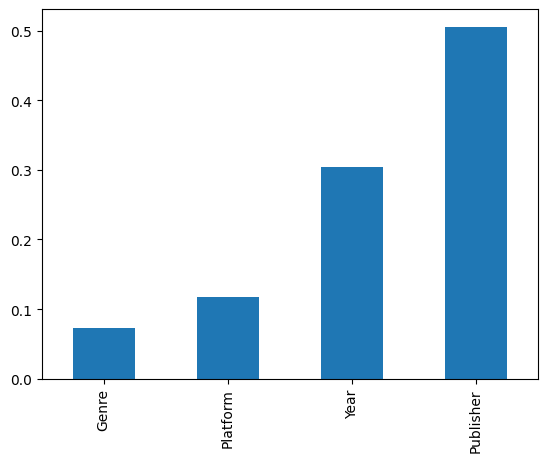

In [39]:
from sklearn.tree import DecisionTreeRegressor



model = DecisionTreeRegressor(max_depth=5, random_state=42)
model.fit(x, y)

combined_importance = pd.Series(model.feature_importances_, index=x.columns).sort_values(ascending=True)
combined_importance.plot.bar()
print(combined_importance)

we find that the name and genre are way more relevant when testing feauture importance than the publisher meaning the model found a relationship between genre and name

<h1 align = "center"> 2 Tuned models

In [40]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [41]:
df = df.dropna()
print(df.isnull().sum())

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor,  ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from category_encoders import BinaryEncoder
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score

base_models = {
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Extra Trees": ExtraTreesRegressor(),
    "XGBoost": XGBRegressor()
}

param_grids = {
    "Decision Tree": {
        'max_depth': [3, 5, 8, 12, 15, None],
        'min_samples_split': randint(2, 21),
        'min_samples_leaf': randint(1,5),
        'criterion': ['squared_error', 'friedman_mse'],
        'ccp_alpha': uniform(0.0, 0.05)
    },
    "Random Forest": {
        'n_estimators': randint(100,801),
        'max_depth': randint(1,15),
        'min_samples_leaf': randint(1,5),
        'max_features': ['sqrt', 'log2'],
        'bootstrap': [True]
    },
    "Extra Trees": {
        'n_estimators': randint(100,501),
        'max_depth': [5, 10, 20, None],
        'min_samples_split': randint(2, 11),
        'bootstrap': [True, False]
    },
    "XGBoost": {
    'n_estimators':     randint(100, 1001),
    'learning_rate':    uniform(0.01, 0.09),
    'max_depth':        randint(3, 10),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma':            uniform(0, 0.2)
    }
}


x = df.drop(columns = ["Rank","Name","NA_Sales","EU_Sales","JP_Sales","Other_Sales","Global_Sales"])
y = df["Global_Sales"]
y = np.log1p(y)


x_train33,x_test33,y_train33,y_test33 = train_test_split(x,y,test_size=0.3,random_state=42)
encoder = BinaryEncoder(cols=["Publisher", "Platform", "Genre"])
x_train33 = encoder.fit_transform(x_train33)
x_test33  = encoder.transform(x_test33)


print(f"{'Model':<25} | {'Train R2':<10} | {'Test R2':<10} | {'Variance':<10} |  {'bias':<10}| {'MAE':<10}")
print("-" * 100)

for name,base in base_models.items():
    params = param_grids[name]

    randomsearch = RandomizedSearchCV(base,params,n_iter=100,cv=5,scoring = 'r2',n_jobs=-1,random_state=42)
    model = randomsearch.fit(x_train33,y_train33)

    train_preds_actual = np.expm1(model.predict(x_train33))
    test_preds_actual  = np.expm1(model.predict(x_test33))
    y_train_actual     = np.expm1(y_train33)
    y_test_actual      = np.expm1(y_test33)

    train_r2 = r2_score(y_train_actual, train_preds_actual)
    r2       = r2_score(y_test_actual, test_preds_actual)

    bias = 1 - train_r2
    variance =  train_r2 - r2
    mae = metrics.mean_absolute_error(y_test_actual, test_preds_actual)


    print(f"{name:<20}   | {train_r2:.4f}   |   {r2:.4f}   |  {variance:.4f}    |   {bias:.2f}   |   ${mae:.2f}" )


Model                     | Train R2   | Test R2    | Variance   |  bias      | MAE       
----------------------------------------------------------------------------------------------------
Decision Tree          | 0.0555   |   0.0300   |  0.0255    |   0.94   |   $0.50
Random Forest          | 0.2368   |   0.0737   |  0.1631    |   0.76   |   $0.45
Extra Trees            | 0.2807   |   0.0968   |  0.1839    |   0.72   |   $0.45
XGBoost                | 0.2251   |   0.0650   |  0.1600    |   0.77   |   $0.45


```
Model                     | Train R2   | Test R2    | Variance   |  bias      | MAE
----------------------------------------------------------------------------------------------------
Decision Tree          | 0.8349   |   0.6310   |  0.2039    |   0.17   |   $0.13
Random Forest          | 0.8490   |   0.4014   |  0.4476    |   0.15   |   $0.18
Extra Trees            | 1.0000   |   0.8382   |  0.1618    |   0.00   |   $0.01
XGBoost                | 0.9592   |   0.6751   |  0.2841    |   0.04   |   $0.05
```

<h4 align = "center"> 2 preparing the data pipeline </h4>

<h4 align = "center"> 2 separating target and feautures + numerical and categorical data </h4>
notice that rank might tell the model information about the targets, for this reason we will be removing the rank

In [43]:
df_aux = df_aux.drop(["Rank"], axis =  1)
df_aux.info()

<class 'pandas.DataFrame'>
Index: 16341 entries, 0 to 16597
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          16341 non-null  str    
 1   Platform      16341 non-null  str    
 2   Year          16341 non-null  int16  
 3   Genre         16341 non-null  str    
 4   Publisher     16341 non-null  str    
 5   NA_Sales      16341 non-null  float64
 6   EU_Sales      16341 non-null  float64
 7   JP_Sales      16341 non-null  float64
 8   Other_Sales   16341 non-null  float64
 9   Global_Sales  16341 non-null  float64
dtypes: float64(5), int16(1), str(4)
memory usage: 1.3 MB


we will be splitting the df into targets Y and feautures X <br>
we will also split numerical and categorical data in order to prepare the feautures independently

In [44]:
from category_encoders import BinaryEncoder
from sklearn.preprocessing import FunctionTransformer
from category_encoders import TargetEncoder

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
X = df_aux.drop(columns = ["NA_Sales","EU_Sales","JP_Sales","Other_Sales","Global_Sales"])
y = df_aux["Global_Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train = np.log1p(y_train)
y_test = np.log1p(y_test)
numerical = ["Year"]
categorical = ['Name','Platform','Publisher','Genre']

#the numerical part
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
])
#the categorical part
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="constant", fill_value="none")),
    ('encoder', BinaryEncoder()) #cols=['Platform', 'Publisher', 'Genre','Name'])
])
#splits data and runs the 2 sides
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical),
    ("cat", categorical_pipeline, categorical),
])



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

pipelines = {
    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]),
    "Extra Trees": Pipeline([
        ("preprocessor", preprocessor),
        ("model", ExtraTreesRegressor(random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(random_state=42))
    ]),
}

param_grids = {
    "Decision Tree": {
        'model__max_depth': [3, 5, 8, 12, 15, None],
        'model__min_samples_split': randint(2, 21),
        'model__min_samples_leaf': randint(1, 5),
        'model__criterion': ['squared_error', 'friedman_mse'],
        'model__ccp_alpha': uniform(0.0, 0.05)
    },
    "Random Forest": {
        'model__n_estimators': randint(100, 801),
        'model__max_depth': randint(1, 15),
        'model__min_samples_leaf': randint(1, 5),
        'model__max_features': ['sqrt', 'log2'],
        'model__bootstrap': [True]
    },
    "Extra Trees": {
        'model__n_estimators': randint(100, 501),
        'model__max_depth': [5, 10, 20, None],
        'model__min_samples_split': randint(2, 11),
        'model__bootstrap': [True, False]
    },
    "XGBoost": {
        'model__n_estimators':     randint(100, 1001),
        'model__learning_rate':    uniform(0.01, 0.09),
        'model__max_depth':        randint(3, 10),
        'model__subsample':        uniform(0.6, 0.4),
        'model__colsample_bytree': uniform(0.6, 0.4),
        'model__gamma':            uniform(0, 0.2)
    }
}

results = {}
for name, pipeline in pipelines.items():
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grids[name],
        n_iter=50,
        cv=5,
        scoring='r2',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train, y_train)

    y_pred = search.best_estimator_.predict(X_test)
    score = r2_score(np.expm1(y_test), np.expm1(y_pred))

    results[name] = {
        "best_score_cv": search.best_score_,
        "test_score": score,
        "best_params": search.best_params_
    }
    print(f"{name}: cv={search.best_score_:.4f} | test={score:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Decision Tree: cv=0.1420 | test=0.0225
Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [ ]:
pipelines = {
    "random_forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]),
    "xgboost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]),
    "extra_tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", ExtraTreesRegressor(random_state=42))
    ]),
    "gradient_boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(random_state=42))
    ]),
}

results = {}
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    results[name] = score
    print(f"{name}: {score:.4f}")


for numerical values, in this case year alone, simple imputer will be used, it will "Replace missing values using a descriptive statistic","If “most_frequent”, then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value" (sklearn SimpleImputer) <br>
the reason I am using 2 pipelines is due to the fact that I want to account for year too.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.base import clone

models = {
    "decision tree" : DecisionTreeRegressor(),
    "random forest" : RandomForestRegressor(),
    "extra trees" : ExtraTreesRegressor(),
    "xgboost" : XGBRegressor(),
    "adaboost" : AdaBoostRegressor(),
}

param_grids = {
    "decision tree": {
        'model__max_depth': [3, 5, 8, 12, 15, None],
        'model__min_samples_split': randint(2, 21),
        'model__min_samples_leaf': randint(1, 5),
        'model__criterion': ['squared_error', 'friedman_mse'],
        'model__ccp_alpha': uniform(0.0, 0.05)
    },
    "random forest": {
        'model__n_estimators': randint(100, 801),
        'model__max_depth': randint(1, 15),
        'model__min_samples_leaf': randint(1, 5),
        'model__max_features': ['sqrt', 'log2'],
        'model__bootstrap': [True]
    },
    "extra trees": {
        'model__n_estimators': randint(100, 501),
        'model__max_depth': [5, 10, 20, None],
        'model__min_samples_split': randint(2, 11),
        'model__bootstrap': [True, False]
    },
    "xgboost": {
        'model__n_estimators':     randint(100, 1001),
        'model__learning_rate':    uniform(0.01, 0.09),
        'model__max_depth':        randint(3, 10),
        'model__subsample':        uniform(0.6, 0.4),
        'model__colsample_bytree': uniform(0.6, 0.4),
        'model__gamma':            uniform(0, 0.2)
    },
    "adaboost": {
        'model__n_estimators': randint(50, 501),
        'model__learning_rate': uniform(0.01, 0.99),
        'model__loss': ['linear', 'square', 'exponential']
    },
}



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)


print(f"{'Model':<20} | {'Train R2':<10} | {'Test R2':<10} | {'Variance':<10} | {'Bias':<10} | {'MAE':<10}")
print("-" * 90)

for name, base in models.items():
    pipeline = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', clone(base))
    ])

    params = param_grids[name]

    search = RandomizedSearchCV(
        pipeline, params,
        n_iter=100, cv=5,
        scoring='r2', n_jobs=-1, random_state=42
    )
    search.fit(X_train, y_train_log)

    train_preds = np.expm1(search.predict(X_train))
    test_preds  = np.expm1(search.predict(X_test))

    train_r2 = r2_score(y_train, train_preds)
    test_r2  = r2_score(y_test,  test_preds)
    bias     = 1 - train_r2
    variance = train_r2 - test_r2
    mae      = mean_absolute_error(y_test, test_preds)
    print(y_train.describe())
    print(y_train_log.describe())
    print(f"{name:<20} | {train_r2:.4f}     | {test_r2:.4f}     | {variance:.4f}   | {bias:.4f}     | ${mae:.2f}")


```
decision tree          | 0.1808   |   -0.0929   |  0.0448    |   0.94   |   $0.61
random forest          | 0.6930   |   0.0785   |  0.0202    |   0.84   |   $0.56
```

In [ ]:
#scatterplot of sales per year, we are trying to see any linear trends in our data in order to decide if we want to use a linear model or not
"""
plt.figure()
sns.scatterplot(data = df, x="Year", y="Global_Sales")
plt.show()
"""

In [ ]:
#using regplot you can get a general ideea of how a line will fit to you data, in this case the line is almost straight and we can observe heteroscedasticity, the spread is not consistent, from 2005- 2016 the has been a rise in sales, but the line is not tilted upwords in our case since there are many datapoints close to 0
"""
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Global_Sales'] = pd.to_numeric(df['Global_Sales'], errors='coerce')


plt.figure(figsize=(10, 6))
sns.regplot(data=df, x="Year", y="Global_Sales",line_kws={"color": "red"})
plt.show()
"""

In [ ]:
"""
x = np.array(df["Platform"].value_counts())
x.sort()
print(x)
counts = df["Platform"].value_counts()
mapping = df["Platform"].map(counts) <=10
final = mapping.values.tolist()
y =  df.iloc[final]
print(len(y))
"""